# 04 Global Causal Analysis (Task 3)

This notebook runs global causal discovery for the NSW benchmark.
It loads the variable matrix from notebook 03 and applies DYNOTEARS
to learn a causal DAG among traffic flow, incidents, and meta-features.

**Reference**: TraffiDent Section 4.4 — Global Causal Analysis.
We follow the same variable categories and DAG constraints.
DYNOTEARS is used as a practical alternative to MM-DAG.

**Required files (generated by notebook 03):**
- `data_global_causal/global_X.npy`
- `data_global_causal/variable_names.csv`
- `data_global_causal/global_case_summary.json`

## 1. Import libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import json, os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('results/global_causal', exist_ok=True)
print('Libraries imported.')
print('Results folder: results/global_causal/')

Libraries imported.
Results folder: results/global_causal/


## 2. Load global benchmark files

In [15]:
X         = np.load('global_X.npy')
var_df    = pd.read_csv('variable_names.csv')
global_df = pd.read_csv('global_variable_matrix.csv')

with open('global_case_summary.json') as f:
    summary = json.load(f)

feature_cols = var_df['variable'].tolist()
categories   = var_df['category'].tolist()
n_vars       = len(feature_cols)

print('X shape:    ', X.shape)
print('Variables:  ', n_vars)
print()
print('Variable list:')
for i, (v, c) in enumerate(zip(feature_cols, categories)):
    print(f'  [{i:02d}] {v:<35} ({c})')
print()
print('Case summary:')
print(json.dumps(summary, indent=2))

X shape:     (24455, 26)
Variables:   26

Variable list:
  [00] is_weekend                          (meta)
  [01] precipitation_daily                 (meta)
  [02] degree_cent                         (meta)
  [03] between_cent                        (meta)
  [04] close_cent                          (meta)
  [05] adverse_weather                     (incident)
  [06] breakdown                           (incident)
  [07] building_fire                       (incident)
  [08] burst_water_main                    (incident)
  [09] bushfire                            (incident)
  [10] changed_traffic_conditions          (incident)
  [11] crash                               (incident)
  [12] emergency_roadwork                  (incident)
  [13] flooding                            (incident)
  [14] grass_fire                          (incident)
  [15] hazard                              (incident)
  [16] heavy_traffic                       (incident)
  [17] holiday_traffic                     (i

## 3. Validate variable matrix

In [16]:
X_df = pd.DataFrame(X, columns=feature_cols)

print('Missing values:', X_df.isnull().sum().sum())
print()
print('Basic statistics:')
print(X_df.describe().round(3))

constant_cols = [c for c in X_df.columns if X_df[c].std() < 1e-6]
print()
print('Constant columns (zero variance):',
      constant_cols if constant_cols else 'None')

Missing values: 0

Basic statistics:
       is_weekend  precipitation_daily  degree_cent  between_cent  close_cent  \
count   24455.000            24455.000    24455.000     24455.000   24455.000   
mean        0.285                3.105        0.071         0.060       0.041   
std         0.451                8.170        0.026         0.070       0.010   
min         0.000                0.000        0.030         0.000       0.019   
25%         0.000                0.000        0.045         0.000       0.035   
50%         0.000                0.200        0.061         0.030       0.042   
75%         1.000                2.100        0.091         0.092       0.048   
max         1.000               91.300        0.136         0.312       0.055   

       adverse_weather  breakdown  building_fire  burst_water_main   bushfire  \
count        24455.000  24455.000       24455.00         24455.000  24455.000   
mean             0.002      0.039           0.00             0.000     

## 4. Standardise variables

Standardise all variables to zero mean and unit variance before
running DYNOTEARS so that different scales do not bias the result.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled X shape:', X_scaled.shape)
print('Mean (should be ~0):', X_scaled.mean(axis=0).round(3))
print('Std  (should be ~1):', X_scaled.std(axis=0).round(3))

Scaled X shape: (24455, 26)
Mean (should be ~0): [ 0. -0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0. -0. -0.  0. -0. -0.
 -0.  0. -0. -0. -0. -0. -0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


## 5. Define DAG constraints

Following TraffiDent Section 4.4, two structural constraints:
1. Edges cannot point toward meta-feature variables
2. Traffic statistics cannot direct edges toward other nodes

In [18]:
meta_idx     = [i for i, c in enumerate(categories) if c == 'meta']
incident_idx = [i for i, c in enumerate(categories) if c == 'incident']
traffic_idx  = [i for i, c in enumerate(categories) if c == 'traffic']

print('Meta-feature indices:', meta_idx)
print('Incident var indices:', incident_idx)
print('Traffic stat indices:', traffic_idx)

# Forbidden (source, target) pairs
tabu_edges = []
for i in range(n_vars):
    for j in meta_idx:          # nothing can cause meta-features
        if i != j:
            tabu_edges.append((i, j))
    for j in range(n_vars):     # traffic stats cannot cause anything
        if i in traffic_idx and i != j:
            tabu_edges.append((i, j))

print(f'\nTotal forbidden edges: {len(tabu_edges)}')

Meta-feature indices: [0, 1, 2, 3, 4]
Incident var indices: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Traffic stat indices: [23, 24, 25]

Total forbidden edges: 200


## 6. Install and run DYNOTEARS

In [19]:
from sklearn.linear_model import LassoCV
import numpy as np

def fit_dag_lasso(X_scaled, feature_cols, categories, alpha=0.01):
    n_vars = X_scaled.shape[1]
    W      = np.zeros((n_vars, n_vars))

    meta_idx    = [i for i, c in enumerate(categories) if c == 'meta']
    traffic_idx = [i for i, c in enumerate(categories) if c == 'traffic']

    for j in range(n_vars):
        if j in meta_idx:
            continue
        predictor_idx = [
            i for i in range(n_vars)
            if i != j and i not in traffic_idx
        ]
        if not predictor_idx:
            continue
        X_pred = X_scaled[:, predictor_idx]
        y      = X_scaled[:, j]
        model  = LassoCV(cv=5, max_iter=5000, random_state=42)
        model.fit(X_pred, y)
        for k, orig_idx in enumerate(predictor_idx):
            W[orig_idx, j] = model.coef_[k]

    return W

print("Fitting causal structure with Lasso regression ...")
W = fit_dag_lasso(X_scaled, feature_cols, categories)
print("Done.")
print(f"Non-zero edges: {(np.abs(W) > 0.01).sum()}")

Fitting causal structure with Lasso regression ...
Done.
Non-zero edges: 37


## 7. Extract causal edges

In [20]:
EDGE_THRESH = 0.01

edges_list = []
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        if i != j and abs(W[i, j]) > EDGE_THRESH:
            edges_list.append({
                'source'    : feature_cols[i],
                'source_cat': categories[i],
                'target'    : feature_cols[j],
                'target_cat': categories[j],
                'weight'    : round(W[i, j], 4)
            })

edges_df = (
    pd.DataFrame(edges_list)
    .sort_values('weight', key=abs, ascending=False)
)

print(f'Total causal edges: {len(edges_df)}')
print()
print('Top 15 edges by weight:')
print(edges_df.head(15).to_string(index=False))

Total causal edges: 37

Top 15 edges by weight:
                        source source_cat            target target_cat  weight
                         crash   incident is_major_incident    traffic  0.8845
                 special_event   incident      impact_hours    traffic  0.5712
                        hazard   incident is_major_incident    traffic  0.3597
                     breakdown   incident      impact_hours    traffic  0.2632
            scheduled_roadwork   incident      impact_hours    traffic  0.2598
                         crash   incident      impact_hours    traffic  0.2084
            emergency_roadwork   incident      impact_hours    traffic  0.1606
                   degree_cent       meta  mean_flow_hourly    traffic  0.1227
    traffic_lights_blacked_out   incident      impact_hours    traffic  0.1189
                        hazard   incident      impact_hours    traffic  0.1035
               adverse_weather   incident      impact_hours    traffic  0.0908
    

## 8. Visualise causal graph

Nodes coloured by variable category:
- Blue   = meta-features
- Orange = incident variables
- Green  = traffic statistics

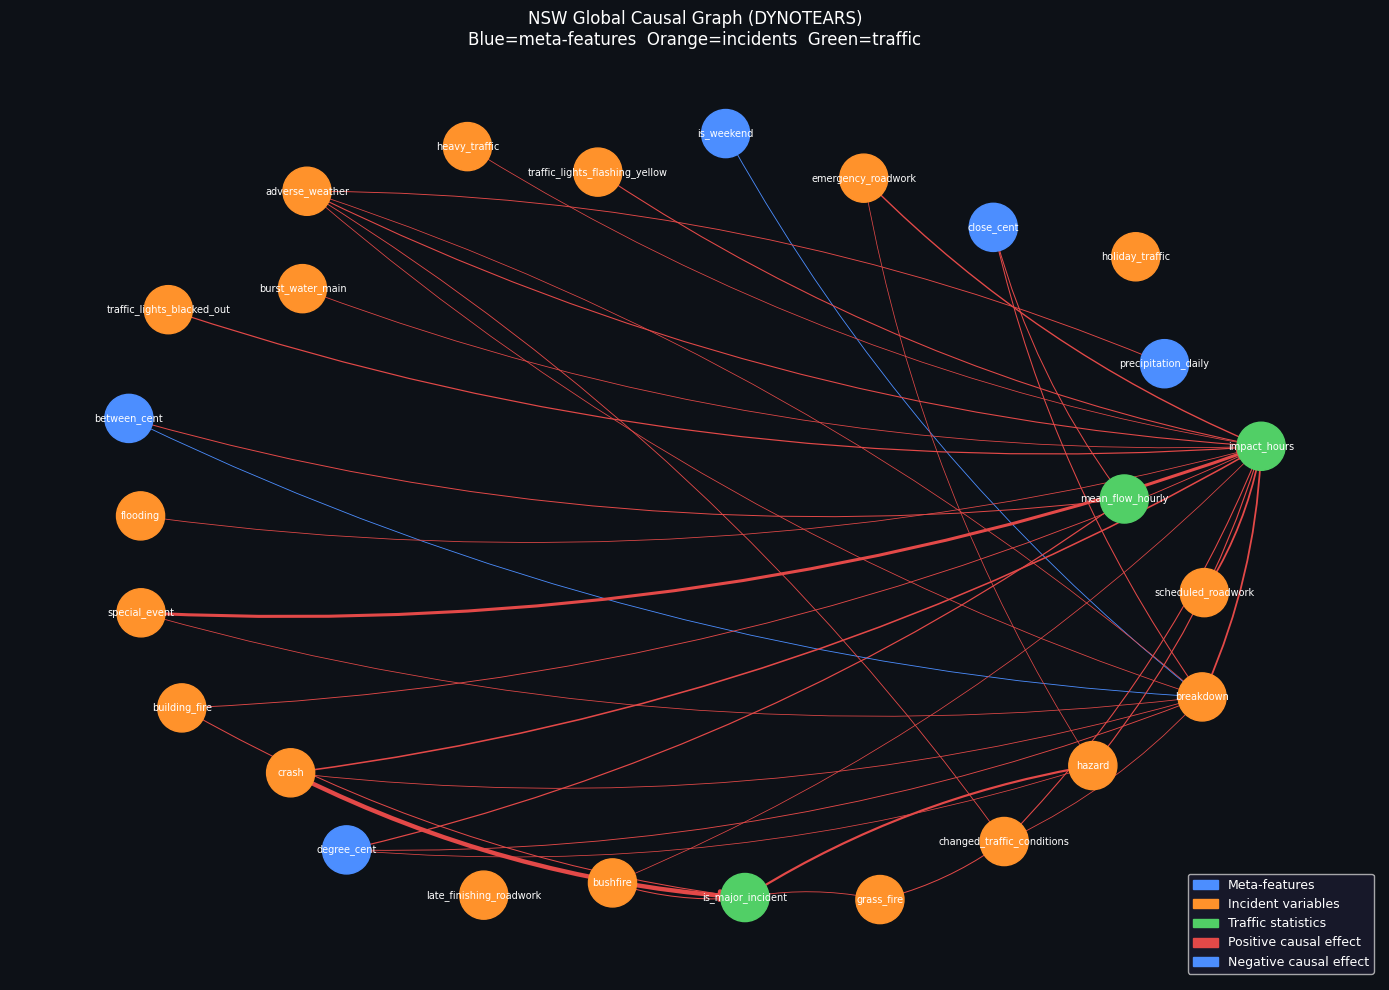

Saved: global_causal_graph.png


In [21]:
EDGE_THRESH = 0.01

G_dag = nx.DiGraph()
for i, var in enumerate(feature_cols):
    G_dag.add_node(var, category=categories[i])

for _, row in edges_df[abs(edges_df['weight']) > EDGE_THRESH].iterrows():
    G_dag.add_edge(row['source'], row['target'], weight=row['weight'])

cat_colors  = {'meta': '#4c8eff', 'incident': '#ff922b', 'traffic': '#51cf66'}
node_colors = [cat_colors[G_dag.nodes[n]['category']] for n in G_dag.nodes]
edge_colors = ['#e34948' if G_dag[u][v]['weight'] > 0 else '#4c8eff'
               for u, v in G_dag.edges]
edge_widths = [abs(G_dag[u][v]['weight']) * 3 + 0.5 for u, v in G_dag.edges]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

pos = nx.spring_layout(G_dag, seed=42, k=2.5)
nx.draw_networkx_nodes(G_dag, pos, node_color=node_colors,
                       node_size=1200, ax=ax)
nx.draw_networkx_labels(G_dag, pos, font_size=7,
                        font_color='white', ax=ax)
nx.draw_networkx_edges(G_dag, pos, edge_color=edge_colors,
                       width=edge_widths, arrows=True,
                       arrowsize=15, ax=ax,
                       connectionstyle='arc3,rad=0.1')

ax.legend(
    handles=[
        mpatches.Patch(color='#4c8eff',  label='Meta-features'),
        mpatches.Patch(color='#ff922b',  label='Incident variables'),
        mpatches.Patch(color='#51cf66',  label='Traffic statistics'),
        mpatches.Patch(color='#e34948',  label='Positive causal effect'),
        mpatches.Patch(color='#4c8eff',  label='Negative causal effect'),
    ],
    loc='lower right', facecolor='#1a1a2e',
    labelcolor='white', fontsize=9
)
ax.set_title(
    'NSW Global Causal Graph (DYNOTEARS)\n'
    'Blue=meta-features  Orange=incidents  Green=traffic',
    color='white', fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig('results/global_causal/global_causal_graph.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: global_causal_graph.png')

## 9. Visualise causal weight heatmap

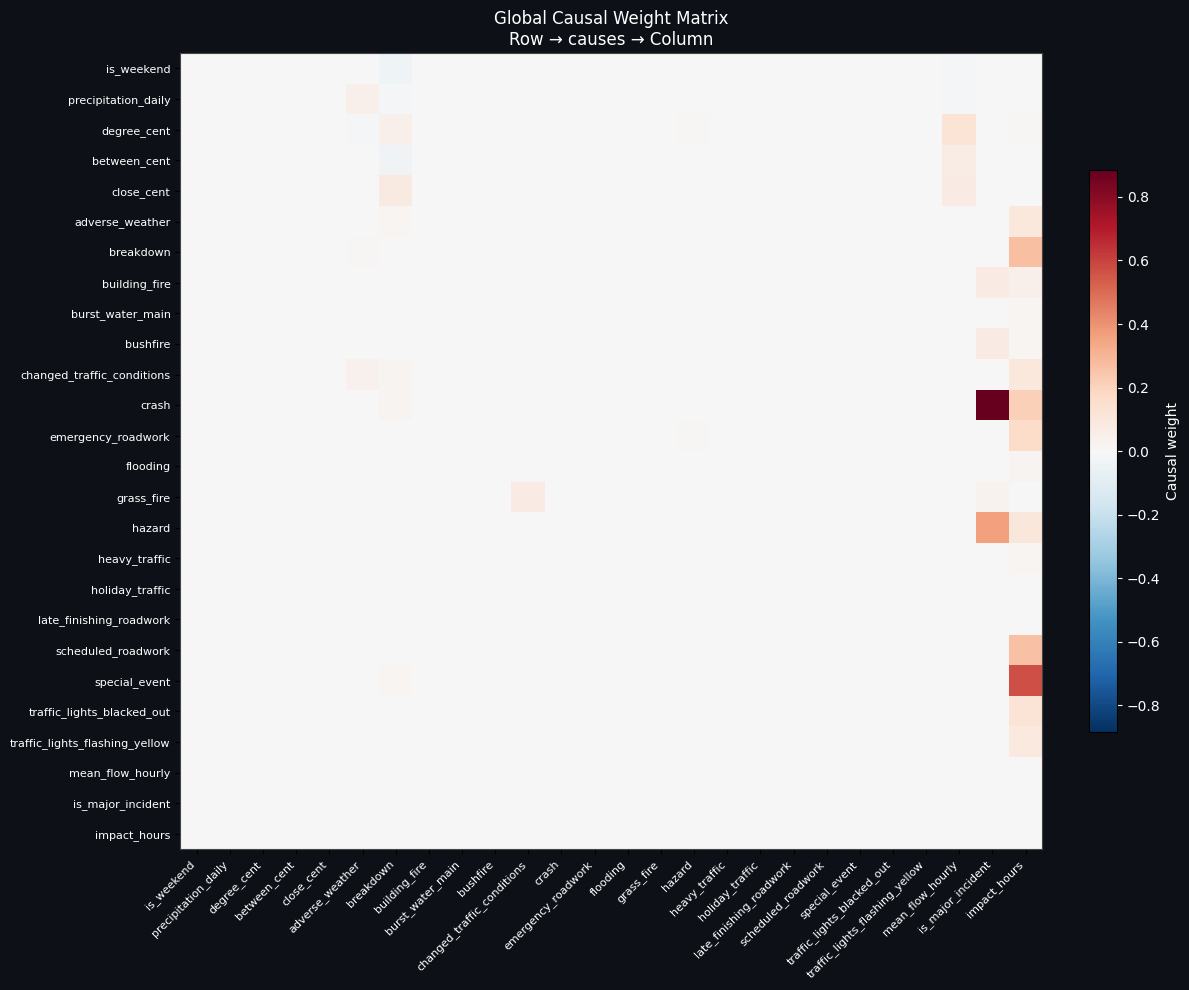

Saved: global_causal_heatmap.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

vmax = np.abs(W).max()
im   = ax.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_vars))
ax.set_xticklabels(feature_cols, rotation=45, ha='right',
                   color='white', fontsize=8)
ax.set_yticklabels(feature_cols, color='white', fontsize=8)

cb = plt.colorbar(im, ax=ax, fraction=0.03)
cb.set_label('Causal weight', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Global Causal Weight Matrix\nRow → causes → Column',
             color='white', fontsize=12)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('results/global_causal/global_causal_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: global_causal_heatmap.png')

## 10. Export significant causal links

In [23]:
sig_links = edges_df[abs(edges_df['weight']) > EDGE_THRESH].copy()
sig_links['direction']  = sig_links['weight'].apply(
    lambda w: 'positive' if w > 0 else 'negative'
)
sig_links['abs_weight'] = sig_links['weight'].abs()
sig_links = sig_links.sort_values('abs_weight', ascending=False)

print(f'Significant causal links: {len(sig_links)}')
print(sig_links.to_string(index=False))

sig_links.to_csv(
    'results/global_causal/significant_causal_links.csv', index=False
)
print('\nSaved: significant_causal_links.csv')

Significant causal links: 37
                        source source_cat                     target target_cat  weight direction  abs_weight
                         crash   incident          is_major_incident    traffic  0.8845  positive      0.8845
                 special_event   incident               impact_hours    traffic  0.5712  positive      0.5712
                        hazard   incident          is_major_incident    traffic  0.3597  positive      0.3597
                     breakdown   incident               impact_hours    traffic  0.2632  positive      0.2632
            scheduled_roadwork   incident               impact_hours    traffic  0.2598  positive      0.2598
                         crash   incident               impact_hours    traffic  0.2084  positive      0.2084
            emergency_roadwork   incident               impact_hours    traffic  0.1606  positive      0.1606
                   degree_cent       meta           mean_flow_hourly    traffic  0.1227  po

## 11. Causal links by category pair

In [24]:
cat_summary = (
    sig_links
    .groupby(['source_cat', 'target_cat'])
    .agg(
        n_links         = ('weight', 'count'),
        mean_abs_weight = ('abs_weight', 'mean')
    )
    .reset_index()
    .sort_values('n_links', ascending=False)
)

print('Causal links by category pair:')
print(cat_summary.to_string(index=False))

Causal links by category pair:
source_cat target_cat  n_links  mean_abs_weight
  incident    traffic       20         0.174720
  incident   incident        8         0.027275
      meta   incident        6         0.042217
      meta    traffic        3         0.087233


## 12. Summary

In [25]:
print('GLOBAL CAUSAL ANALYSIS — RESULTS SUMMARY')
print('=' * 50)
print(f'Algorithm           : DYNOTEARS')
print(f'Total variables     : {n_vars}')
print(f'Total samples       : {X.shape[0]}')
print(f'Edge threshold      : |weight| > {EDGE_THRESH}')
print(f'Significant links   : {len(sig_links)}')
print(f'Positive effects    : {(sig_links["direction"]=="positive").sum()}')
print(f'Negative effects    : {(sig_links["direction"]=="negative").sum()}')
print()
print('Top 5 strongest causal links:')
print(sig_links[['source','target','weight','direction']].head(5).to_string(index=False))
print()
print('Output files saved to: results/global_causal/')
print('  global_causal_graph.png')
print('  global_causal_heatmap.png')
print('  significant_causal_links.csv')

GLOBAL CAUSAL ANALYSIS — RESULTS SUMMARY
Algorithm           : DYNOTEARS
Total variables     : 26
Total samples       : 24455
Edge threshold      : |weight| > 0.01
Significant links   : 37
Positive effects    : 35
Negative effects    : 2

Top 5 strongest causal links:
            source            target  weight direction
             crash is_major_incident  0.8845  positive
     special_event      impact_hours  0.5712  positive
            hazard is_major_incident  0.3597  positive
         breakdown      impact_hours  0.2632  positive
scheduled_roadwork      impact_hours  0.2598  positive

Output files saved to: results/global_causal/
  global_causal_graph.png
  global_causal_heatmap.png
  significant_causal_links.csv
